In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.figure(figsize=(8, 8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

## 傅里叶变换

(<Axes: title={'center': 'magnitude_spectrum'}>,
 Text(0.5, 1.0, 'magnitude_spectrum'),
 (-0.5, 1278.5, 1705.5, -0.5))

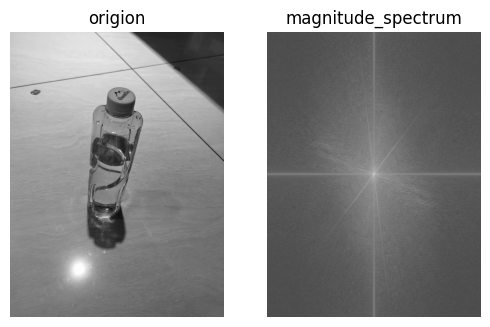

In [ ]:
# 读取图像，第二个参数 0 表示以灰度图模式读取
img = cv2.imread('./assets/1.jpg', 0)

# 将图像数据类型转换为 float32 类型，因为傅里叶变换需要浮点型数据
img_float32 = np.float32(img)

# 执行傅里叶变换，cv2.DFT_COMPLEX_OUTPUT 表示输出是复数形式（包含实部和虚部）
# 傅里叶变换的结果是频域表示
dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)

# 使用 np.fft.fftshift 将零频率分量移动到图像的中心位置
# 傅里叶变换的结果默认零频率分量在图像的角落，使用 fftshift 可以将其移动到中心，便于观察
dft_shit = np.fft.fftshift(dft)

# 计算频域的幅度谱。cv2.magnitude 计算复数的幅度（模长），dft_shit[:,:,0] 是实部，dft_shit[:,:,1] 是虚部
# 通过对幅度谱取对数并乘以 20 来增强图像细节（映射到0~255之间），便于显示和观察
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shit[:,:,0], dft_shit[:,:,1]))

# 使用 Matplotlib 绘制图像和幅度谱
plt.figure(figsize=(16, 16))

# 显示原始灰度图，plt.axis('off') 禁用坐标轴显示
plt.subplot(251), plt.imshow(img, 'gray'), plt.title("origion"), plt.axis('off')

# 显示幅度谱图，plt.axis('off') 禁用坐标轴显示
plt.subplot(252), plt.imshow(magnitude_spectrum, 'gray'), plt.title("magnitude_spectrum"), plt.axis('off')

(<Axes: title={'center': 'low_hz_keep'}>,
 Text(0.5, 1.0, 'low_hz_keep'),
 (-0.5, 1278.5, 1705.5, -0.5))

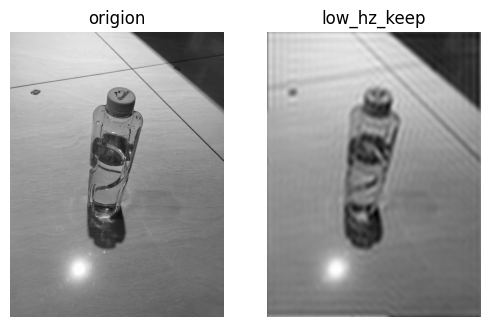

In [ ]:
# 读取图像，第二个参数 0 表示以灰度图模式读取
img = cv2.imread('./assets/1.jpg', 0)

# 将图像数据类型转换为 float32 类型，因为傅里叶变换需要浮点型数据
img_float32 = np.float32(img)

# 执行傅里叶变换，cv2.DFT_COMPLEX_OUTPUT 表示输出是复数形式（包含实部和虚部）
# 傅里叶变换的结果是频域表示
dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)

# 使用 np.fft.fftshift 将零频率分量移动到图像的中心位置
# 傅里叶变换的结果默认零频率分量在图像的角落，使用 fftshift 可以将其移动到中心，便于观察
dft_shit = np.fft.fftshift(dft)

rows, cols = img.shape
center_row, center_col = int(rows/2), int(cols/2)

# 设置低通滤波的阈值，这个值决定了低频部分的大小
threshold = 30
# 创建一个和图像尺寸相同的零矩阵，用来作为掩膜
mask = np.zeros((rows, cols, 2), np.uint8)
# 创建一个正方形的中心区域，这个区域内的频率成分会被保留
# 我们在掩膜的中心部分创建一个大小为 (2*threshold)x(2*threshold) 的矩形，值为 1
# 这表示保留中心区域的频率成分（低频成分）
mask[center_row - threshold:center_row + threshold, center_col - threshold: center_col + threshold] = 1
# 将掩膜应用到频谱上，保留中心区域的低频成分
fshift = dft_shit * mask
# 将频谱进行反向移位，使零频率回到图像的角落
f_ishift = np.fft.ifftshift(fshift)
# 执行逆傅里叶变换，从频率域回到空间域，恢复图像
img_back = cv2.idft(f_ishift)

# 计算频域的幅度谱。cv2.magnitude 计算复数的幅度（模长），dft_shit[:,:,0] 是实部，dft_shit[:,:,1] 是虚部
img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

# 使用 Matplotlib 绘制图像和幅度谱
plt.figure(figsize=(16, 16))

# 显示原始灰度图，plt.axis('off') 禁用坐标轴显示
plt.subplot(251), plt.imshow(img, 'gray'), plt.title("origion"), plt.axis('off')

# 显示幅度谱图，plt.axis('off') 禁用坐标轴显示
plt.subplot(252), plt.imshow(img_back, 'gray'), plt.title("low_hz_keep"), plt.axis('off')

(<Axes: title={'center': 'high_hz_keep'}>,
 Text(0.5, 1.0, 'high_hz_keep'),
 (-0.5, 1278.5, 1705.5, -0.5))

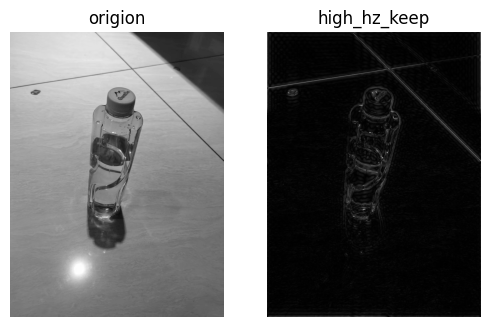

In [19]:
# 读取图像，第二个参数 0 表示以灰度图模式读取
img = cv2.imread('./assets/1.jpg', 0)

# 将图像数据类型转换为 float32 类型，因为傅里叶变换需要浮点型数据
img_float32 = np.float32(img)

# 执行傅里叶变换，cv2.DFT_COMPLEX_OUTPUT 表示输出是复数形式（包含实部和虚部）
# 傅里叶变换的结果是频域表示
dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)

# 使用 np.fft.fftshift 将零频率分量移动到图像的中心位置
# 傅里叶变换的结果默认零频率分量在图像的角落，使用 fftshift 可以将其移动到中心，便于观察
dft_shit = np.fft.fftshift(dft)

rows, cols = img.shape
center_row, center_col = int(rows/2), int(cols/2)

# 高通滤波
threshold = 37
mask = np.ones((rows, cols, 2), np.uint8)
mask[center_row - threshold:center_row + threshold, center_col - threshold: center_col + threshold] = 0

fshift = dft_shit * mask
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)

# 计算频域的幅度谱。cv2.magnitude 计算复数的幅度（模长），dft_shit[:,:,0] 是实部，dft_shit[:,:,1] 是虚部
img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

# 使用 Matplotlib 绘制图像和幅度谱
plt.figure(figsize=(16, 16))

# 显示原始灰度图，plt.axis('off') 禁用坐标轴显示
plt.subplot(251), plt.imshow(img, 'gray'), plt.title("origion"), plt.axis('off')

# 显示幅度谱图，plt.axis('off') 禁用坐标轴显示
plt.subplot(252), plt.imshow(img_back, 'gray'), plt.title("high_hz_keep"), plt.axis('off')

### 为什么傅里叶变换后的频谱低频部分位于角落？

这是傅里叶变换的一种特性和频谱的传统显示方式，通常涉及到如何处理信号的**零频率分量**和**频率成分的排列**。

#### 1. **傅里叶变换的基本原理**

傅里叶变换将时域或空间域的信号转换到频域，表示信号包含的不同频率成分。对于一张图像，傅里叶变换将图像从空间域转换为频率域，生成的是一个复数数组，其中每个复数包含了幅度和相位信息：

* **低频成分**：表示图像的大体轮廓、整体亮度和形状。
* **高频成分**：表示图像的细节、边缘、噪声等。

在传统的傅里叶变换计算中，频率从零频率到最高频率排列：

* **零频率**代表信号的“平均”或“直流”分量，通常对应图像的整体亮度。
* **高频率**代表图像的变化或细节部分，例如边缘或噪声。

#### 2. **频率分量的位置**

傅里叶变换的计算过程中，频率成分是按照一个特定的顺序排列的。通常，计算出来的频谱中，**零频率分量**会出现在图像的**左上角**，然后随着频率增大，信号会从左到右逐渐增大。这个排列方式被称为**低频在角落，高频在中心**。

#### 3. **为什么低频在角落，高频在中心？**

1. **傅里叶变换的默认输出顺序：**
   在傅里叶变换的标准实现中，频谱的零频率部分通常位于数组的**左上角**，而随着频率增高，数据点会按从左到右的顺序排列。

2. **频率分量的位置：**
   对于二维图像而言：

   * **零频率**：通常出现在频谱的左上角，表示图像的整体均衡亮度。
   * **高频率**：随着频率的增大，逐渐从图像的左上角到右下角移动。

   这意味着图像的中心区域对应的是**低频成分**，而图像的四个角落则对应的是**高频成分**。

3. **零频率分量偏移：**

   * 由于计算出来的频谱是按“从低到高”的频率顺序排列的，所以为了观察时更为直观，**使用了 `fftshift` 函数来将零频率分量移到频谱的**中心区域\*\*，即图像的中间部分。
   * 这种做法让我们在查看频谱时，低频成分位于图像中心，高频成分位于角落，符合人们的直觉和习惯，使得频谱更容易观察和分析。

#### 4. **`fftshift`函数的作用**

`fftshift` 是傅里叶变换中的一个常用函数，它将频谱中的零频率分量从左上角移到频谱的中心。这样，低频部分就出现在频谱的中央，而高频部分则位于图像的角落。

* **没有使用 `fftshift`** 时，频谱的零频率分量通常位于图像的左上角。
* **使用 `fftshift`** 后，零频率分量会移动到图像的中心位置，低频成分显示在中央区域。

### 5. **总结**

* **傅里叶变换后的频谱**：默认情况下，频率从低到高排列，零频率分量位于图像的左上角。
* 通过使用 `fftshift`，我们将零频率分量移动到图像中心，从而让频谱中的低频成分位于中心，而高频成分则位于角落。
* 这种频谱排列方式让我们能够更直观地看到图像中的低频和高频成分，更好地进行频谱分析。
